# Dueling Double DQN with OpenSpiel 2048

This notebook trains a **Dueling Double DQN** agent on the OpenSpiel 2048 environment.

Compared with vanilla DQN, this combines two improvements:
- **Dueling DQN**: Decomposes Q-values into state value V(s) and action advantage A(s,a) for better learning.
- **Double DQN**: Uses the online network to select actions and the target network to evaluate them, reducing overestimation bias.

The rest of the training pipeline remains the same.

In [19]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pyspiel
import torch
import torch.optim as optim
from tqdm.auto import tqdm

print("PyTorch version:", torch.__version__)
print("OpenSpiel version:", pyspiel.__version__ if hasattr(pyspiel, "__version__") else "unknown")
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

PyTorch version: 2.5.1+cu121
OpenSpiel version: 1.6.12
CUDA available: True
Device: cuda


## 1. Load and inspect OpenSpiel 2048

OpenSpiel represents a game as a `Game` object and a playthrough position as a `State`. The 2048 game includes randomness, so we resolve chance nodes inside the environment wrapper.

In [20]:
game = pyspiel.load_game("2048")
state = game.new_initial_state()

game_type = game.get_type()
short_name = game_type.short_name if hasattr(game_type, "short_name") else "2048"

print("Registered game:", short_name)
print("Num distinct actions:", game.num_distinct_actions())
print("Observation tensor shape:", game.observation_tensor_shape())
print("Observation tensor size:", game.observation_tensor_size())
print("Max chance outcomes:", game.max_chance_outcomes())
print("Max game length:", game.max_game_length())
print("Min / Max utility:", game.min_utility(), game.max_utility())
print()
print("Initial state is chance node:", state.is_chance_node())
print("Initial state string:")
print(state)

Registered game: 2048
Num distinct actions: 4
Observation tensor shape: [4, 4]
Observation tensor size: 16
Max chance outcomes: 33
Max game length: 8192
Min / Max utility: 0.0 20480.0

Initial state is chance node: True
Initial state string:
    0    0    0    0
    0    0    0    0
    0    0    0    0
    0    0    0    0



## 2. Helper functions and environment wrapper

We reuse the repository helpers and the thin `OpenSpiel2048Env` wrapper.

In [21]:
from app.helpers import extract_obs, legal_actions, parse_board_numbers, auto_resolve_chance_nodes, epsilon_by_step
from app.open_spiel_2048_env import OpenSpiel2048Env

test_state = game.new_initial_state()
auto_resolve_chance_nodes(test_state, np.random.default_rng(0))
print("Observation shape after resolving initial chance:", extract_obs(test_state).shape)
print("Legal actions:", legal_actions(test_state))
print("Board (best effort):")
print(parse_board_numbers(test_state))
print()
print(test_state)

Observation shape after resolving initial chance: (16,)
Legal actions: [0, 1, 2, 3]
Board (best effort):
[[0 0 0 0]
 [2 0 0 0]
 [0 0 2 0]
 [0 0 0 0]]

    0    0    0    0
    2    0    0    0
    0    0    2    0
    0    0    0    0



In [22]:
# Quick random rollout
env = OpenSpiel2048Env(seed=123)
obs = env.reset()

total_reward = 0.0
steps = 0
done = False

while not done and steps < 20:
    action = random.choice(env.legal_actions())
    obs, reward, done, info = env.step(action)
    total_reward += reward
    steps += 1

print("Random steps:", steps)
print("Partial return:", total_reward)
print("Legal actions now:", env.legal_actions())
env.render()

Random steps: 20
Partial return: 76.0
Legal actions now: [0, 1, 2, 3]
    0    2    0    0
    4    8    0    0
    4   16    4    0
    2    4    4    0



## 3. Replay buffer and Dueling Q-network

The Dueling DQN architecture decomposes Q(s,a) = V(s) + A(s,a), where V(s) is the state value and A(s,a) is the advantage. This helps learn state values more efficiently.

We use the same replay buffer as before.

In [23]:
from app.replay_buffer import ReplayBuffer, make_legal_mask
from app.dueling_q_network import DuelingQNetwork
from app.helpers import masked_greedy_action, double_dqn_update

In [24]:
# Hyperparameters
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

NUM_EPISODES = 300  # increase for stronger results
BUFFER_SIZE = 50_000
BATCH_SIZE = 128
GAMMA = 0.99
LR = 1e-3
TARGET_SYNC_EVERY = 250
LEARN_START = 1_000
LEARN_EVERY = 4
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 20_000
MAX_STEPS_PER_EPISODE = 5_000
GRAD_CLIP = 10.0

train_env = OpenSpiel2048Env(seed=SEED)
obs_dim = train_env.obs_dim
num_actions = train_env.num_actions

q_net = DuelingQNetwork(obs_dim, num_actions).to(DEVICE)
target_net = DuelingQNetwork(obs_dim, num_actions).to(DEVICE)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=LR)
replay = ReplayBuffer(BUFFER_SIZE)

print("obs_dim =", obs_dim)
print("num_actions =", num_actions)

obs_dim = 16
num_actions = 4


## 4. Training loop

The loop combines Dueling DQN (network architecture) with Double DQN (target computation).

In [25]:
episode_returns = []
episode_lengths = []
loss_history = []
eval_returns = []
max_tiles_per_episode = []
illegal_action_attempts = []

global_step = 0

for episode in tqdm(range(1, NUM_EPISODES + 1), desc="Training"):
    obs = train_env.reset(seed=SEED + episode)
    done = False
    ep_return = 0.0
    ep_len = 0
    max_tile = 0
    illegal_attempts = 0

    while not done and ep_len < MAX_STEPS_PER_EPISODE:
        eps = epsilon_by_step(
            global_step,
            eps_start=EPS_START,
            eps_end=EPS_END,
            eps_decay_steps=EPS_DECAY_STEPS,
        )
        legal = train_env.legal_actions()
        legal_mask = make_legal_mask(num_actions, legal)

        if obs is not None and len(obs) > 0:
            max_tile = max(max_tile, int(np.max(obs)))

        with torch.no_grad():
            q_vals = q_net(torch.tensor(np.asarray([obs]), dtype=torch.float32, device=DEVICE))
            q_vals_np = q_vals.cpu().numpy()[0]

        action = masked_greedy_action(
            q_net=q_net,
            obs=obs,
            legal_actions_list=legal,
            num_actions=num_actions,
            epsilon=eps,
            device=DEVICE,
        )

        if eps > 0 and len(legal) < num_actions:
            best_raw_action = np.argmax(q_vals_np)
            if best_raw_action not in legal:
                illegal_attempts += 1

        next_obs, reward, done, info = train_env.step(action)
        next_legal = info["legal_actions"] if not done else []
        next_legal_mask = make_legal_mask(num_actions, next_legal)

        replay.add(obs, action, reward, next_obs, done, legal_mask, next_legal_mask)

        obs = next_obs
        ep_return += reward
        ep_len += 1
        global_step += 1

        if len(replay) >= LEARN_START and global_step % LEARN_EVERY == 0:
            batch = replay.sample(BATCH_SIZE)
            loss = double_dqn_update(
                batch=batch,
                q_net=q_net,
                target_net=target_net,
                optimizer=optimizer,
                gamma=GAMMA,
                grad_clip=GRAD_CLIP,
                device=DEVICE,
            )
            loss_history.append(loss)

        if global_step % TARGET_SYNC_EVERY == 0:
            target_net.load_state_dict(q_net.state_dict())

    episode_returns.append(ep_return)
    episode_lengths.append(ep_len)
    max_tiles_per_episode.append(max_tile)
    illegal_action_attempts.append(illegal_attempts)

    if episode % 20 == 0:
        eval_env = OpenSpiel2048Env(seed=1000 + episode)
        obs_eval = eval_env.reset(seed=2000 + episode)
        done_eval = False
        ret_eval = 0.0
        steps_eval = 0

        while not done_eval and steps_eval < MAX_STEPS_PER_EPISODE:
            legal = eval_env.legal_actions()
            action = masked_greedy_action(
                q_net, obs_eval, legal, num_actions, epsilon=0.0, device=DEVICE
            )
            obs_eval, reward, done_eval, info_eval = eval_env.step(action)
            ret_eval += reward
            steps_eval += 1

        eval_returns.append((episode, ret_eval))

print("Training complete.")

Training:   0%|          | 0/300 [00:00<?, ?it/s]

Training complete.


## 5. Plot learning curves

The plots below track training return, episode length, loss, and maximum tile reached.

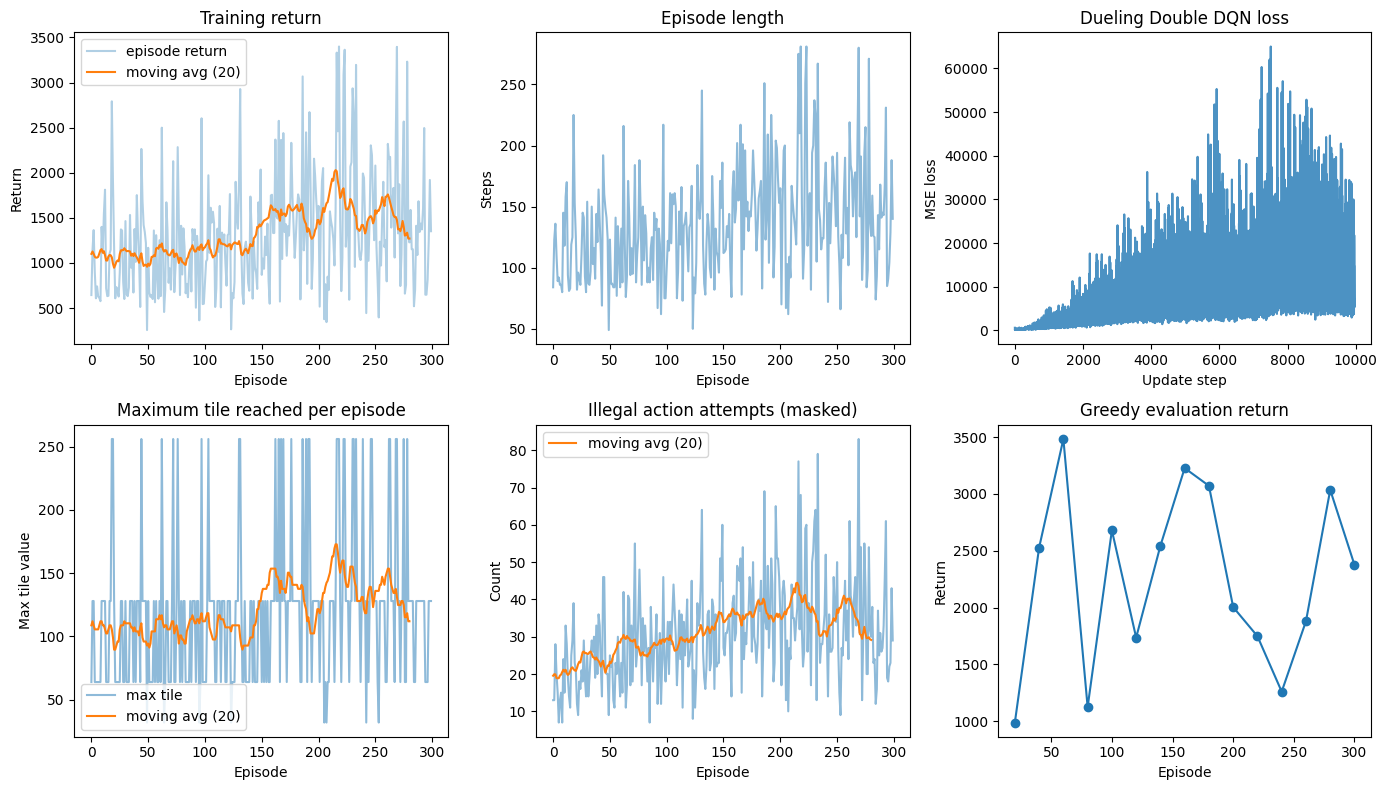

In [26]:
def moving_average(x, w=20):
    if len(x) < w:
        return np.asarray(x)
    return np.convolve(x, np.ones(w) / w, mode="valid")


plt.figure(figsize=(14, 8))

# Original metrics
plt.subplot(2, 3, 1)
plt.plot(episode_returns, alpha=0.35, label="episode return")
ma = moving_average(episode_returns, 20)
plt.plot(range(len(ma)), ma, label="moving avg (20)")
plt.title("Training return")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()

plt.subplot(2, 3, 2)
plt.plot(episode_lengths, alpha=0.5)
plt.title("Episode length")
plt.xlabel("Episode")
plt.ylabel("Steps")

plt.subplot(2, 3, 3)
plt.plot(loss_history, alpha=0.8)
plt.title("Dueling Double DQN loss")
plt.xlabel("Update step")
plt.ylabel("MSE loss")

# New metrics
plt.subplot(2, 3, 4)
plt.plot(max_tiles_per_episode, alpha=0.5, label="max tile")
ma_tiles = moving_average(max_tiles_per_episode, 20)
plt.plot(range(len(ma_tiles)), ma_tiles, label="moving avg (20)")
plt.title("Maximum tile reached per episode")
plt.xlabel("Episode")
plt.ylabel("Max tile value")
plt.legend()

plt.subplot(2, 3, 5)
plt.plot(illegal_action_attempts, alpha=0.5)
ma_illegal = moving_average(illegal_action_attempts, 20)
plt.plot(range(len(ma_illegal)), ma_illegal, label="moving avg (20)")
plt.title("Illegal action attempts (masked)")
plt.xlabel("Episode")
plt.ylabel("Count")
plt.legend()

plt.subplot(2, 3, 6)
if eval_returns:
    eval_eps, eval_vals = zip(*eval_returns)
    plt.plot(eval_eps, eval_vals, marker="o")
    plt.title("Greedy evaluation return")
    plt.xlabel("Episode")
    plt.ylabel("Return")

plt.tight_layout()
plt.show()

## 6. Greedy evaluation and checkpoint

The last cell runs a greedy rollout and saves the trained model.

In [27]:
from app.eval import evaluate_multi_seed, greedy_rollout, save_eval_results


eval_env = OpenSpiel2048Env(seed=999)
greedy_return, rollout_length, greedy_max_tile, greedy_illegal_attempts, rollout = greedy_rollout(
    q_net=q_net,
    env=eval_env,
    num_actions=num_actions,
    max_steps=MAX_STEPS_PER_EPISODE,
    device=DEVICE,
)

print("Greedy evaluation return:", greedy_return)
print("Rollout length:", rollout_length)
print("Greedy max tile:", greedy_max_tile)
print("Greedy illegal action attempts:", greedy_illegal_attempts)
print()
eval_env.render()

output_dir = "./output/dueling-double-dqn"
os.makedirs(output_dir, exist_ok=True)

num_eval_seeds = 100
eval_data = evaluate_multi_seed(
    q_net=q_net,
    env_class=OpenSpiel2048Env,
    num_eval_seeds=num_eval_seeds,
    num_actions=num_actions,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    device=DEVICE,
    seed_offset=5000,
)

npz_path, json_path = save_eval_results(
    eval_data=eval_data,
    output_dir=output_dir,
    num_actions=num_actions,
    obs_dim=obs_dim,
    source_notebook="Dueling Double DQN",
    checkpoint_file="dqn.pt",
)

summary = eval_data["summary"]
print(f"Saved evaluation rollout archive to: {npz_path}")
print(f"Saved evaluation metadata to: {json_path}")
print(f"Saved {len(eval_data['actions'])} transitions across {num_eval_seeds} evaluation episodes.")

print(f"\nResults over {num_eval_seeds} seeds:")
print(f"  Average return:           {summary['avg_return']:.1f} +/- {summary['std_return']:.1f}")
print(f"  Average episode length:   {summary['avg_length']:.1f}")
print(f"  Average max tile:         {summary['avg_max_tile']:.1f}")
print(f"  Average illegal attempts: {summary['avg_illegal_action_attempts']:.1f}")
print(f"  Total illegal attempts:   {summary['total_illegal_action_attempts']}")
print(
    f"\nPer-seed returns: {[f'{r:.1f}' for r in eval_data['episode_returns']]}"
)
print(
    f"Per-seed max tiles: {[f'{t:.0f}' for t in eval_data['max_tiles']]}"
)
print(
    f"Per-seed illegal attempts: {eval_data['episode_illegal_action_attempts'].tolist()}"
)

checkpoint_path = os.path.join(output_dir, "dqn.pt")
torch.save(
    {
        "model_state_dict": q_net.state_dict(),
        "target_state_dict": target_net.state_dict(),
        "obs_dim": obs_dim,
        "num_actions": num_actions,
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "loss_history": loss_history,
    },
    checkpoint_path,
)
print("Saved checkpoint to:", checkpoint_path)

Greedy evaluation return: 2252.0
Rollout length: 193
Greedy max tile: 256
Greedy illegal action attempts: 40

    4    2   32  256
    2   16    2   32
    4    8   32    4
    2    4    8   16

Saved evaluation rollout archive to: ./output/dueling-double-dqn/eval_rollout.npz
Saved evaluation metadata to: ./output/dueling-double-dqn/eval_meta.json
Saved 17012 transitions across 100 evaluation episodes.

Results over 100 seeds:
  Average return:           1747.3 +/- 949.7
  Average episode length:   170.1
  Average max tile:         143.0
  Average illegal attempts: 42.0
  Total illegal attempts:   4203

Per-seed returns: ['692.0', '3136.0', '1660.0', '1756.0', '1028.0', '1756.0', '1880.0', '1116.0', '1168.0', '1472.0', '1560.0', '1412.0', '692.0', '992.0', '1832.0', '1068.0', '1576.0', '816.0', '1148.0', '1140.0', '1564.0', '812.0', '1592.0', '1600.0', '1304.0', '1484.0', '2576.0', '1616.0', '1252.0', '940.0', '1976.0', '1716.0', '1572.0', '1576.0', '1120.0', '1744.0', '3836.0', '896.0